# Usporedba modela: Isolation Forest vs. duboki autoenkoder

Ova bilježnica objedinjuje rezultate obje pojedinačno istrenirane i evaluirane bilježnice (isolation_forest.ipynb i autoencoder.ipynb) radi izravne usporedbe na istom testnom skupu, u skladu s poglavljem 4.6. završnog rada. Ne trenira modele iznova, nego učitava već istrenirane,
spremljene modele iz obje bilježnice.

Datoteke isolation_forest_model.pkl, amount_scaler_if.pkl i time_scaler_if.pkl iz isolation_forest.ipynb, te autoencoder_model.keras iz autoencoder_keras_tensor.ipynb potrebno je učitati
u runtime ove bilježnice (ćelija u nastavku otvara sučelje za učitavanje datoteka).

In [1]:
#!pip install -q kagglehub scikit-learn pandas matplotlib seaborn
!pip install -q joblib
!pip install -q tensorflow

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import time
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    precision_score, recall_score, f1_score, confusion_matrix,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)
from tensorflow import keras

RANDOM_STATE = 42

## 1. Priprema testnog skupa

Ponavlja se identičan postupak podjele i skaliranja kao u obje pojedinačne bilježnice
(kronološka podjela 70:30, RobustScaler prilagođen isključivo na trening skupu), kako bi se
dobio testni skup koji je brojčano identičan onom korištenom u obje originalne evaluacije.

In [2]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(f"{path}/creditcard.csv")

split_idx = int(len(df) * 0.7)
train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

amount_scaler = RobustScaler()
train_df['Amount_scaled'] = amount_scaler.fit_transform(train_df[['Amount']])
test_df['Amount_scaled'] = amount_scaler.transform(test_df[['Amount']])

time_scaler = RobustScaler()
train_df['Time_scaled'] = time_scaler.fit_transform(train_df[['Time']])
test_df['Time_scaled'] = time_scaler.transform(test_df[['Time']])

feature_cols = [c for c in df.columns if c.startswith('V')] + ['Amount_scaled', 'Time_scaled']

X_test = test_df[feature_cols].values
y_test = test_df['Class'].values

print(f"Test: {X_test.shape}, Fraud rate: {y_test.mean() * 100:.4f} %")

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Test: (85443, 30), Fraud rate: 0.1264 %


## 2. Učitavanje istreniranih modela

Pokreni sljedeću ćeliju i učitaj sve četiri datoteke navedene u uvodu.

In [5]:
from google.colab import files
uploaded = files.upload()

Saving amount_scaler_if.pkl to amount_scaler_if.pkl
Saving autoencoder_model.keras to autoencoder_model.keras
Saving isolation_forest_model.pkl to isolation_forest_model.pkl
Saving time_scaler_if.pkl to time_scaler_if.pkl


In [6]:
iso_forest = joblib.load('isolation_forest_model.pkl')
autoencoder = keras.models.load_model('autoencoder_model.keras')

print("Both models successfully loaded.")

Both models successfully loaded.


## 3. Izračun anomalijskih rezultata

Za Isolation Forest koristi se već ustaljena konvencija (veći rezultat = veća anomalnost), a za
autoenkoder pogreška rekonstrukcije (srednja kvadratna pogreška po transakciji).

In [7]:
if_scores = -iso_forest.score_samples(X_test)

ae_reconstructed = autoencoder.predict(X_test, verbose=0)
ae_scores = np.mean(np.square(X_test - ae_reconstructed), axis=1)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


## 4. Usporedba prema evaluacijskim metrikama

Pragovi ispod odgovaraju finalnim konfiguracijama usvojenima u poglavljima 4.4.3. i 4.5.2. završnog rada.

In [9]:
IF_THRESHOLD = 0.5558
AE_THRESHOLD = 1.3905

if_pred = (if_scores >= IF_THRESHOLD).astype(int)
ae_pred = (ae_scores > AE_THRESHOLD).astype(int)

comparison = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-score', 'ROC-AUC', 'PR-AUC'],
    'Isolation Forest': [
        precision_score(y_test, if_pred),
        recall_score(y_test, if_pred),
        f1_score(y_test, if_pred),
        roc_auc_score(y_test, if_scores),
        average_precision_score(y_test, if_scores)
    ],
    'Autoencoder': [
        precision_score(y_test, ae_pred),
        recall_score(y_test, ae_pred),
        f1_score(y_test, ae_pred),
        roc_auc_score(y_test, ae_scores),
        average_precision_score(y_test, ae_scores)
    ]
})
comparison

,Metric,Isolation Forest,Autoencoder
0,Precision,0.088388,0.088372
1,Recall,0.472222,0.703704
2,F1-score,0.148905,0.157025
3,ROC-AUC,0.944809,0.938665
4,PR-AUC,0.053062,0.099789


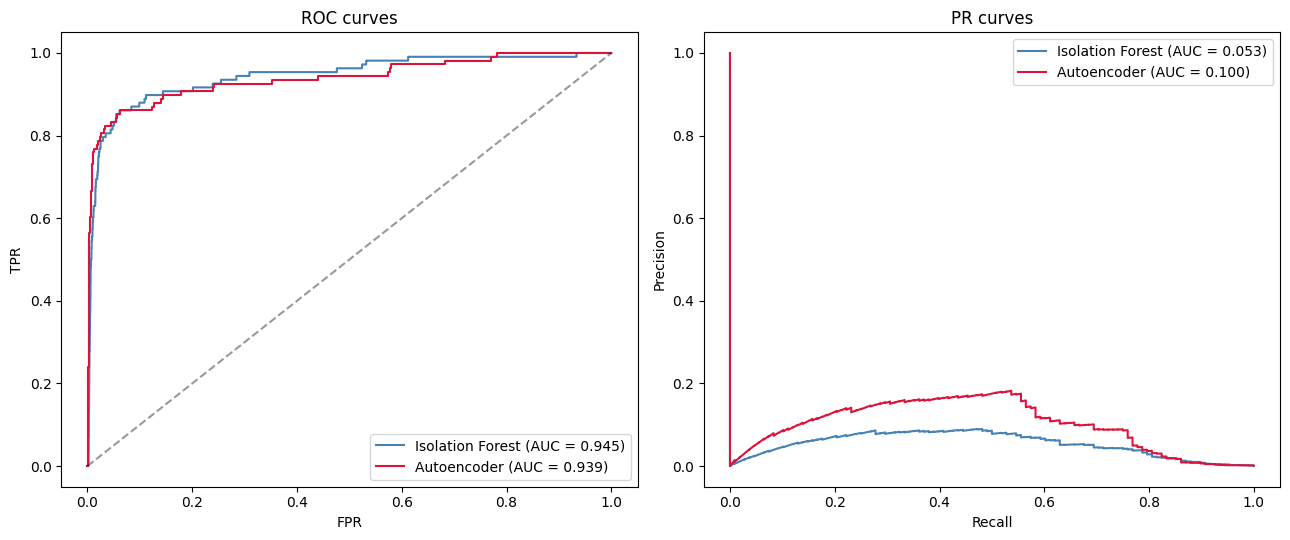

In [10]:
fpr_if, tpr_if, _ = roc_curve(y_test, if_scores)
fpr_ae, tpr_ae, _ = roc_curve(y_test, ae_scores)
prec_if, rec_if, _ = precision_recall_curve(y_test, if_scores)
prec_ae, rec_ae, _ = precision_recall_curve(y_test, ae_scores)

roc_auc_if = roc_auc_score(y_test, if_scores)
roc_auc_ae = roc_auc_score(y_test, ae_scores)
pr_auc_if = average_precision_score(y_test, if_scores)
pr_auc_ae = average_precision_score(y_test, ae_scores)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].plot(fpr_if, tpr_if, label=f'Isolation Forest (AUC = {roc_auc_if:.3f})', color='steelblue')
axes[0].plot(fpr_ae, tpr_ae, label=f'Autoencoder (AUC = {roc_auc_ae:.3f})', color='crimson')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC curves')
axes[0].legend()

axes[1].plot(rec_if, prec_if, label=f'Isolation Forest (AUC = {pr_auc_if:.3f})', color='steelblue')
axes[1].plot(rec_ae, prec_ae, label=f'Autoencoder (AUC = {pr_auc_ae:.3f})', color='crimson')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR curves')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Usporedba vremena obrade

Mjeri se ukupno vrijeme potrebno svakom modelu za izračun anomalijskog rezultata na cijelom
testnom skupu, te prosječno vrijeme po transakciji ( relevantno za procjenu izvedivosti rada u
stvarnom vremenu).

Napomena: apsolutne vrijednosti ovise o hardveru na kojem se bilježnica izvršava (u Colab okruženju to je dijeljeni CPU), pa je usporedba između dva modela
na istom stroju informativnija od same apsolutne brojke.

In [11]:
N_RUNS = 5

if_times = []
for _ in range(N_RUNS):
    start = time.perf_counter()
    _ = iso_forest.score_samples(X_test)
    if_times.append(time.perf_counter() - start)

ae_times = []
for _ in range(N_RUNS):
    start = time.perf_counter()
    _ = autoencoder.predict(X_test, verbose=0)
    ae_times.append(time.perf_counter() - start)

if_avg_total = np.mean(if_times)
ae_avg_total = np.mean(ae_times)
if_per_tx_ms = (if_avg_total / len(X_test)) * 1000
ae_per_tx_ms = (ae_avg_total / len(X_test)) * 1000

timing_comparison = pd.DataFrame({
    'Model': ['Isolation Forest', 'Autoencoder'],
    'Total average time (s)': [if_avg_total, ae_avg_total],
    'Average time per transaction (ms)': [if_per_tx_ms, ae_per_tx_ms]
})
timing_comparison

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


,Model,Total average time (s),Average time per transaction (ms)
0,Isolation Forest,2.455318,0.028736
1,Autoencoder,4.011958,0.046955


## 6. Preklapanje detekcija i provjera potencijala ansambla

Prema preporuci mentora, ansambl dvaju modela ima smisla razmatrati jedino ako se pokaže da modeli prepoznaju različite prijevare i da njihova kombinacija donosi mjerljivo poboljšanje u odnosu na svaki model zasebno. U nastavku se prvo provjerava preklapanje stvarno prepoznatih prijevara (TP) između oba modela, a zatim se testira jednostavna OR-kombinacija (transakcija se označava kao sumnjiva ako je bilo koji od dva modela označi kao takvu).

In [12]:
fraud_idx = np.where(y_test == 1)[0]

if_hits = set(fraud_idx[if_pred[fraud_idx] == 1])
ae_hits = set(fraud_idx[ae_pred[fraud_idx] == 1])

both = if_hits & ae_hits
only_if = if_hits - ae_hits
only_ae = ae_hits - if_hits
missed_by_both = set(fraud_idx) - (if_hits | ae_hits)

print(f"Total number of frauds in test: {len(fraud_idx)}")
print(f"Recognised by both models: {len(both)}")
print(f"Recognised just by Isolation Foresta: {len(only_if)}")
print(f"Recognised just by autoencoder: {len(only_ae)}")
print(f"Missed by both models: {len(missed_by_both)}")

Total number of frauds in test: 108
Recognised by both models: 50
Recognised just by Isolation Foresta: 1
Recognised just by autoencoder: 26
Missed by both models: 31


### Test OR-kombinacije (ansambl)

Ako bi barem jedan od dva modela dovoljno bio dovoljan da se transakcija označi kao sumnjiva,
odziv bi se trebao povećati (jer se hvataju i prijevare koje svaki model zasebno propušta), no
pitanje je po kojoj cijeni u preciznosti.

In [13]:
ensemble_pred = ((if_pred == 1) | (ae_pred == 1)).astype(int)

ensemble_comparison = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-score'],
    'Isolation Forest': [
        precision_score(y_test, if_pred),
        recall_score(y_test, if_pred),
        f1_score(y_test, if_pred)
    ],
    'Autoencoder': [
        precision_score(y_test, ae_pred),
        recall_score(y_test, ae_pred),
        f1_score(y_test, ae_pred)
    ],
    'Ansambl (OR)': [
        precision_score(y_test, ensemble_pred),
        recall_score(y_test, ensemble_pred),
        f1_score(y_test, ensemble_pred)
    ]
})
ensemble_comparison

,Metric,Isolation Forest,Autoencoder,Ansambl (OR)
0,Precision,0.088388,0.088372,0.071561
1,Recall,0.472222,0.703704,0.712963
2,F1-score,0.148905,0.157025,0.130068
